cesta nalezena


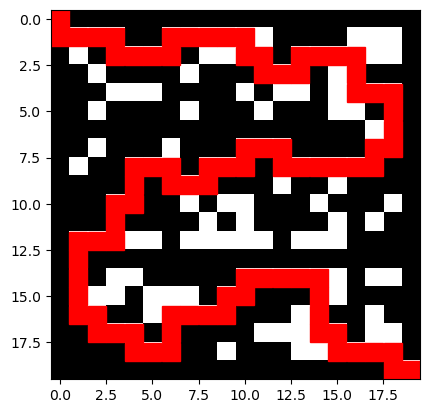

In [7]:
import numpy as np
import csv
from collections import deque
import matplotlib.pyplot as plt
import random
from typing import List, Tuple

class Bludiste:
    """
    Reprezentuje bludiště uložené jako dvourozměrná booleovská matice.

    False znamená průchozí pole
    True znamená zeď

    Attributes:
        parametry: Dvourozměrné numpy pole reprezentující bludiště.
        n: Velikost jedné strany čtvercového bludiště.
    """
    def __init__(self, parametry:np.ndarray):
        self.parametry = parametry
        self.n = parametry.shape[0]

def nacti_data(nazev_souboru: str)-> np.ndarray:
    """
    Načte data ze souboru CSV a převede je na matici typu bool.

    Hodnoty 1 jsou převedeny na True,
    hodnoty 0 na False.

    Args:
        nazev_souboru: Cesta k CSV souboru.

    Returns:
        Dvourozměrné numpy pole typu bool.
    """
    soubor = np.genfromtxt(nazev_souboru, delimiter=",", dtype=int)
    matice = soubor.astype(bool)
    return matice
  
def vykresli_cestu(matice: np.ndarray, trasa:List[Tuple[int, int]], nalezeni: int)->None:
    """
    Vykreslí bludiště a případně nalezenou cestu.

    Funkce zobrazí matici pomocí matplotlibu jako obrázek a pokud byla cesta nalezena,
    zvýrazní daná políčka červeně.

    Args:
        matice: Dvourozměrné numpy pole reprezentující bludiště.
        trasa: Seznam souřadnic cesty ve formátu (x, y).
        nalezeni: True pokud byla cesta nalezena, jinak False.

    Returns:
        None
    """
    plt.imshow(matice, cmap='gray_r', origin='upper')
    if nalezeni ==1:
        for x, y in trasa:
            plt.plot(y,x, marker='s', color='red', markersize=13)

def najdi_cestu(zadane_bludiste: np.ndarray):
    """
    Najde cestu v bludišti pomocí BFS algoritmu.

    Funkce hledá cestu z levého horního rohu (0,0)
    do pravého dolního rohu (n-1,n-1). Pohyb je možný
    pouze po průchozích polích (False).
    
    Nejdříve se do navstiveno a k_prohledani uloží 0,0 = levý horní roh. 
    Pak se ovří sousedé tohoto políčka a vybere se další volné. Oůvodní políčko se uloží jako předchůdce následujícího
    pro rekonstrukci cesty. set - zabrání duplikacím, deque pop.left - princip first in first out

    Args:
        zadane_bludiste: Dvourozměrná numpy matice bludiště.

    Returns:
        tuple:
            - seznam souřadnic cesty (x, y)
            - nalezeno - hodnota, zda byla cesta nalezena
    """

    navstiveno = set()
    k_prohledani = deque()
    k_prohledani.append((0,0))
    navstiveno.add((0,0))

    predchudce = {}
    cesta = []
    nalezeno = 0
    while k_prohledani:
        x, y = k_prohledani.popleft()
        if x==n-1 and y==n-1:
            print ("cesta nalezena")
            nalezeno = 1
            break
        smery = [(0,1), (1,0), (0,-1), (-1,0)]
        random.shuffle(smery)

        for dx, dy in smery:
            nx, ny = x+dx, y+dy

            if 0<=nx<n and 0<=ny<n and not zadane_bludiste[nx,ny] and (nx, ny) not in navstiveno:
                    k_prohledani.append((nx, ny))
                    navstiveno.add((nx, ny))
                    predchudce[(nx, ny)] = (x, y)


    if x != n-1 and y!= n-1:
        print("cesta nenalezena")

    if nalezeno == 1:
        while (x,y) != (0,0):
            
            cesta.append((x,y))
            x, y = predchudce[(x, y)]
        cesta.append((0,0)) 
    vykresli_cestu(bludiste.parametry, cesta, nalezeno)        

data = nacti_data("data/maze_2.csv")
bludiste = Bludiste(data)
n = data.shape[0]
  
najdi_cestu(bludiste.parametry)

